# Logistic Regression with Python

- For this lecture we will be working with the Titanic Data Set from Kaggle. This is a very famous data set and very often is a student's first step in machine learning!

- We'll be trying to predict a classification- survival or deceased. Let's begin our understanding of implementing Logistic Regression in Python for classification.

- We'll use a "semi-cleaned" version of the titanic data set, if you use the data set hosted directly on Kaggle, you may need to do some additional cleaning not shown in this lecture notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
%matplotlib inline

In [2]:
train = pd.read_csv('../datasets/titanic_train.csv')

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploratory Data Analysis

- Let's begin some exploratory data analysis! We'll start by checking out missing data!

## Missing Data

- We can use seaborn to create a simple heatmap to see where we are missing data!

In [5]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

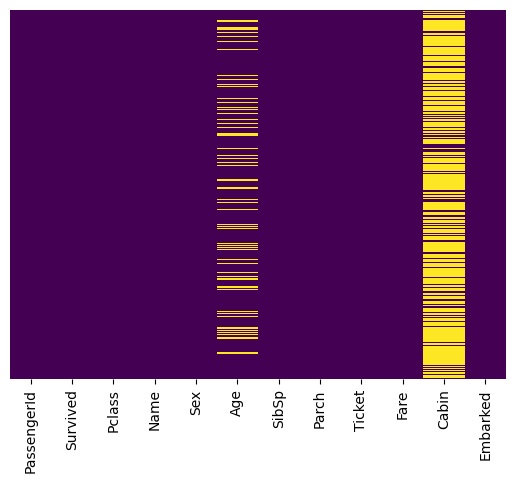

In [6]:
sns.heatmap(train.isnull() , yticklabels=False , cbar = False , cmap = 'viridis')

<Axes: xlabel='Survived', ylabel='count'>

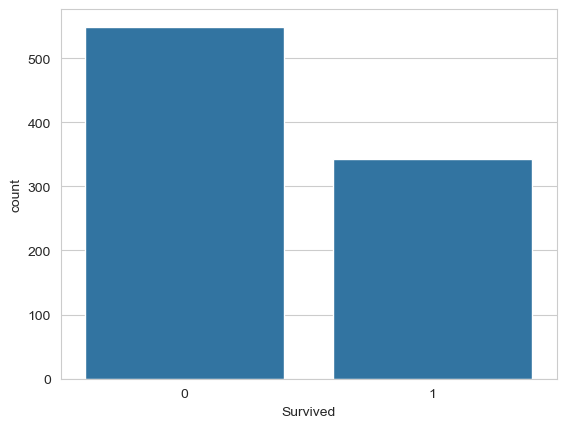

In [6]:
sns.set_style('whitegrid')

sns.countplot(data = train , x = 'Survived')

<Axes: xlabel='Survived', ylabel='count'>

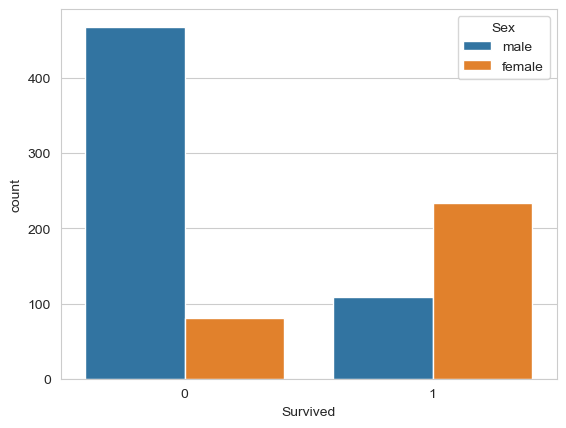

In [8]:
sns.set_style('whitegrid')

sns.countplot(data = train , x = 'Survived' , hue='Sex')

<Axes: xlabel='Survived', ylabel='count'>

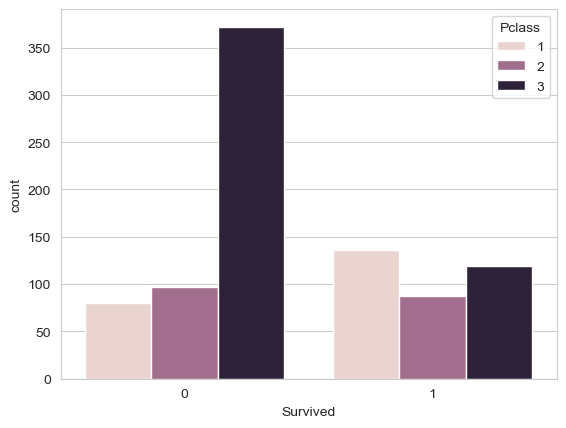

In [10]:
sns.set_style('whitegrid')

sns.countplot(data = train , x = 'Survived' , hue='Pclass')

<Axes: xlabel='Age', ylabel='Count'>

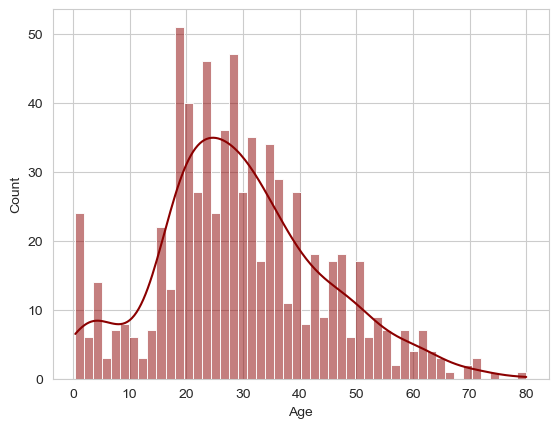

In [22]:
sns.histplot(train['Age'].dropna() , kde=True , color='darkred' ,bins=50)

<Axes: xlabel='SibSp', ylabel='count'>

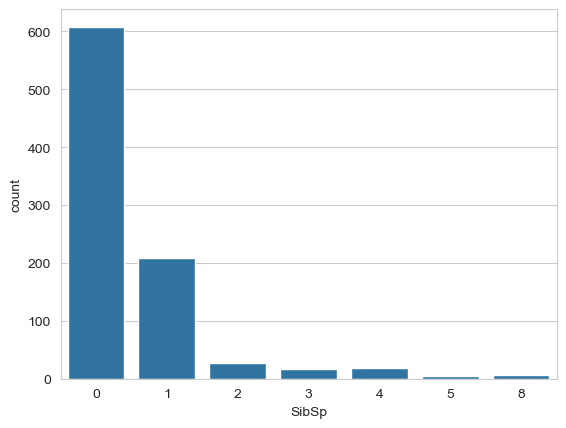

In [23]:
sns.countplot(data = train , x = 'SibSp')

<Axes: >

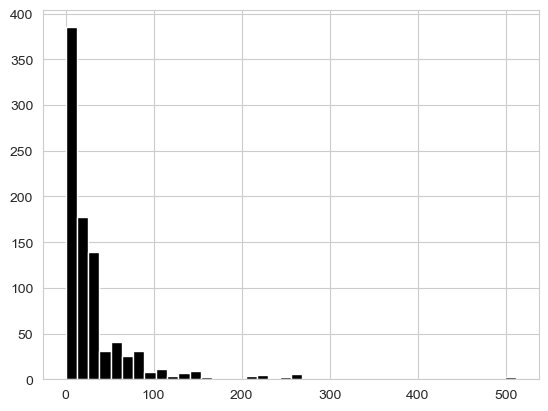

In [25]:
train['Fare'].hist(color='black',bins=40)

<Axes: xlabel='Pclass', ylabel='Age'>

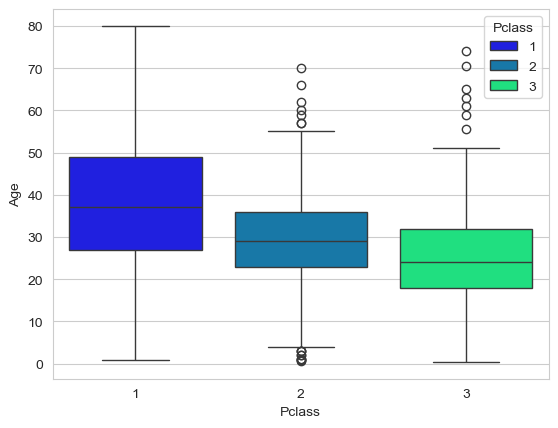

In [49]:
sns.boxplot(x='Pclass' , y='Age' , data = train,hue='Pclass', palette='winter')

In [1]:
def fill_age(cols):
    age = cols.iloc[0]
    pclass = cols.iloc[1]

    if pd.isnull(age):
        if pclass == 1:
            return 37
        elif pclass == 2:
            return 29
        elif pclass == 3:
            return 24
    else:
        return age


In [2]:

train.loc['Age'] = train[['Age' , 'Pclass']].apply(fill_age , axis=1)

sns.heatmap(train.isnull() , yticklabels=False , cbar = False , cmap = 'viridis')

NameError: name 'train' is not defined

In [86]:
train.drop('Cabin' , axis = 1,inplace=True)

In [63]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1.0,0.0,3.0,"Braund, Mr. Owen Harris",male,24.0,1.0,0.0,A/5 21171,7.2500,S
1,2.0,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,37.0,1.0,0.0,PC 17599,71.2833,C
2,3.0,1.0,3.0,"Heikkinen, Miss. Laina",female,24.0,0.0,0.0,STON/O2. 3101282,7.9250,S
3,4.0,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,37.0,1.0,0.0,113803,53.1000,S
4,5.0,0.0,3.0,"Allen, Mr. William Henry",male,24.0,0.0,0.0,373450,8.0500,S


<Axes: >

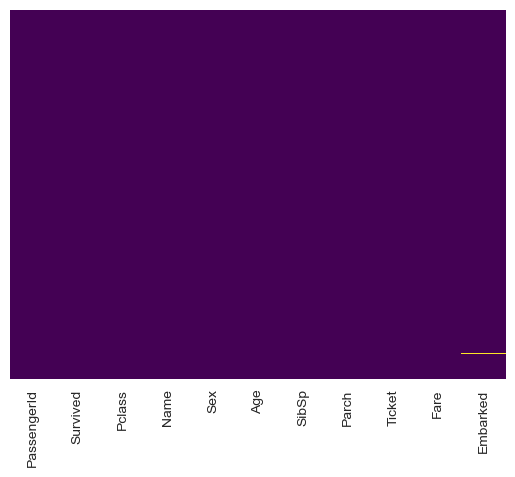

In [64]:
sns.heatmap(train.isnull() , yticklabels=False , cbar = False , cmap = 'viridis')

In [82]:
pd.get_dummies(train['Embarked'] , drop_first=True).head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [83]:
sex = pd.get_dummies(train['Sex'] , drop_first=True)
embark = pd.get_dummies(train['Embarked'] , drop_first=True)

In [84]:
train.drop(['Sex','Embarked','Name','Ticket'] , axis = 1,inplace = True)

In [87]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [88]:
train = pd.concat([train,sex,embark] , axis = 1)

In [89]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


#### Create a violinplot for fare vs survival. How does distribution differ?

<Axes: xlabel='Survived', ylabel='Fare'>

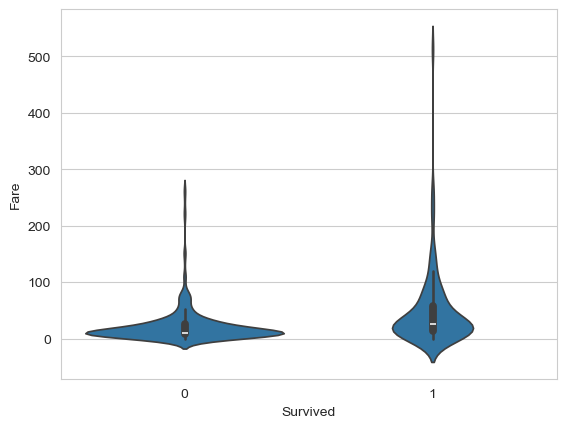

In [93]:
sns.violinplot(data = train,y='Fare' , x='Survived')

- Compare age distribution across passenger classes using a boxplot. What socioeconomic insight can you infer?

<Axes: xlabel='Pclass', ylabel='Age'>

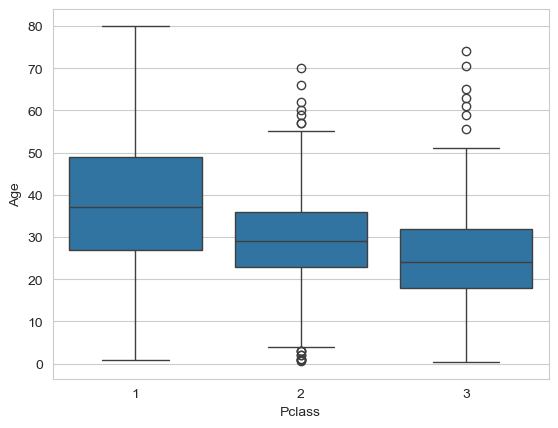

In [94]:
sns.boxplot(data = train , x = 'Pclass' , y='Age')

#### Plot survival vs class with gender as hue. How does gender impact survival within each class?

<Axes: xlabel='Pclass', ylabel='Survived'>

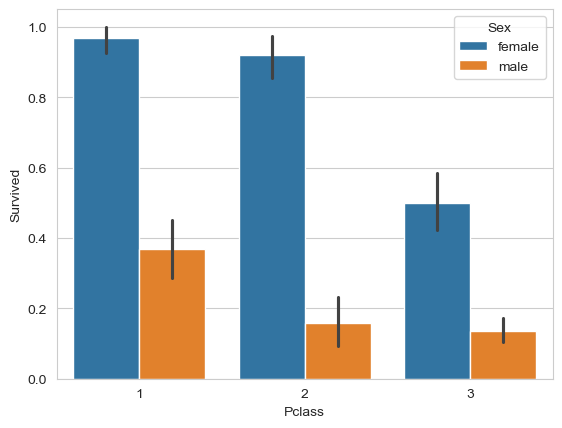

In [107]:
sns.barplot(data = train , x = 'Pclass' , y='Survived' , hue='Sex' )

#### Use histplot with hue="survived" for age. Do certain age groups survive more?

<Axes: xlabel='Age', ylabel='Count'>

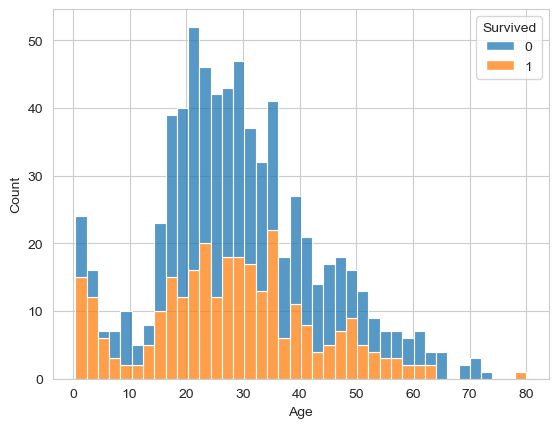

In [108]:
sns.histplot(data=train, x='Age', hue='Survived', bins=40, multiple='stack')

#### Create a countplot of embarkation with survival as hue. Any surprising trends?

<Axes: xlabel='Embarked', ylabel='count'>

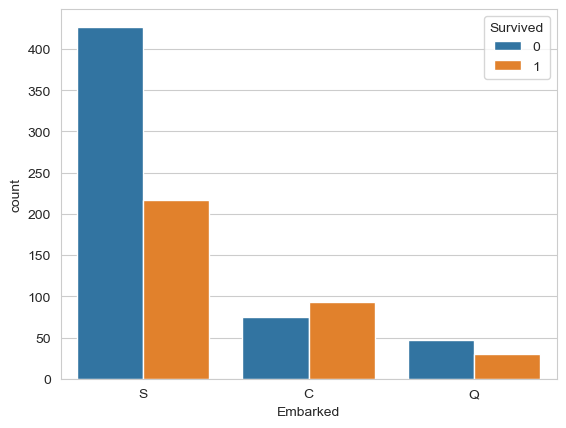

In [109]:
sns.countplot(data = train , x = 'Embarked' , hue = "Survived")

#### Use scatterplot to visualize age vs fare. Do higher fares correlate with certain age groups?

<Axes: xlabel='Age', ylabel='Fare'>

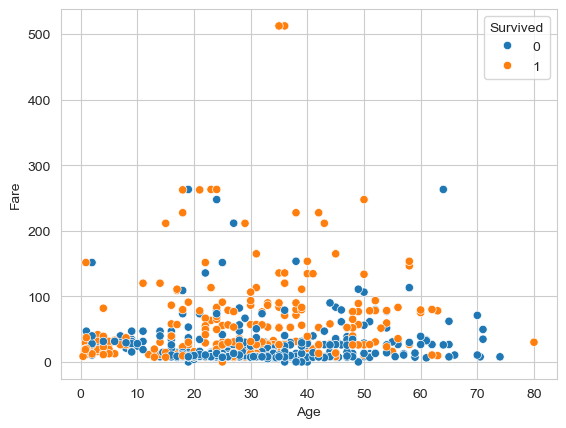

In [115]:
sns.scatterplot(data = train , x = 'Age' ,y='Fare' , hue='Survived')

#### Create a pairplot for key features (age, fare, pclass, survived). What patterns emerge?

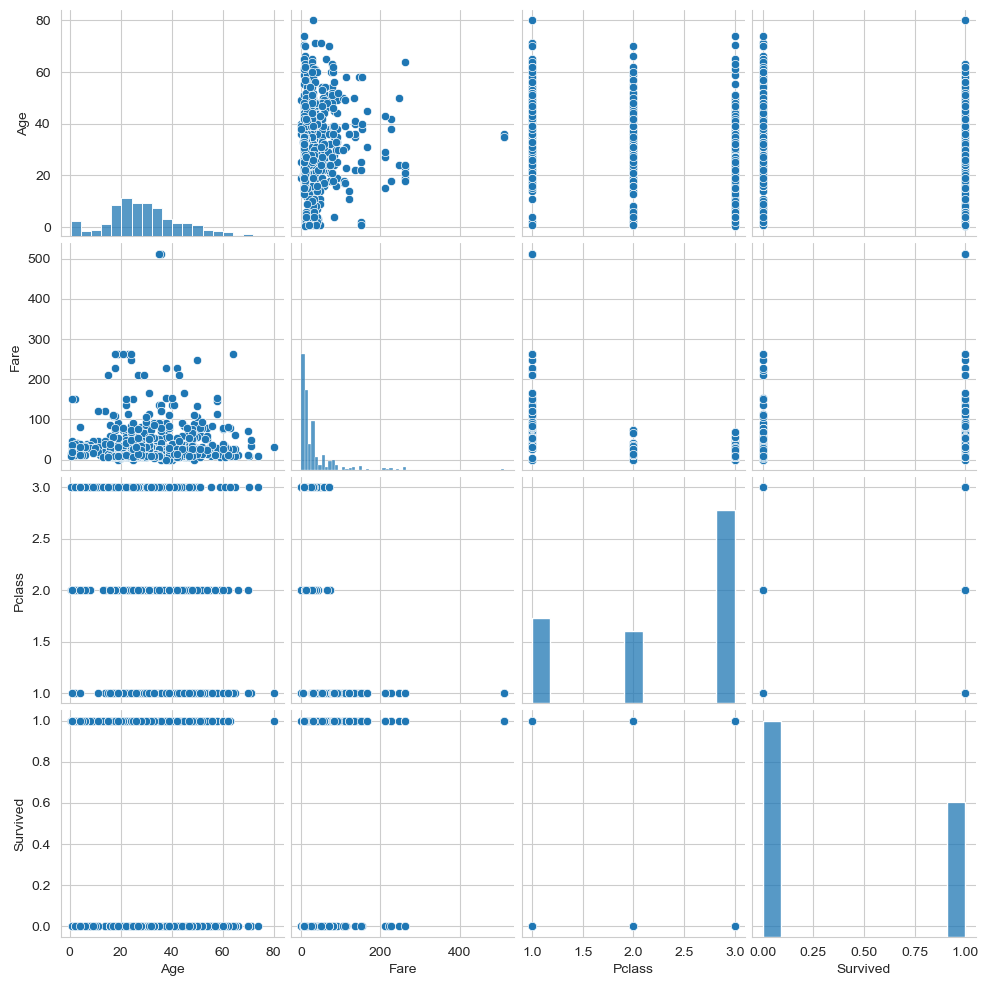

In [120]:
sns.pairplot(data = train , kind = 'scatter' , x_vars=['Age', 'Fare', 'Pclass', 'Survived'] ,  y_vars=['Age', 'Fare', 'Pclass', 'Survived'])

#### Visualize average fare paid by each class. Does it align with expectations?

<Axes: xlabel='Pclass', ylabel='Fare'>

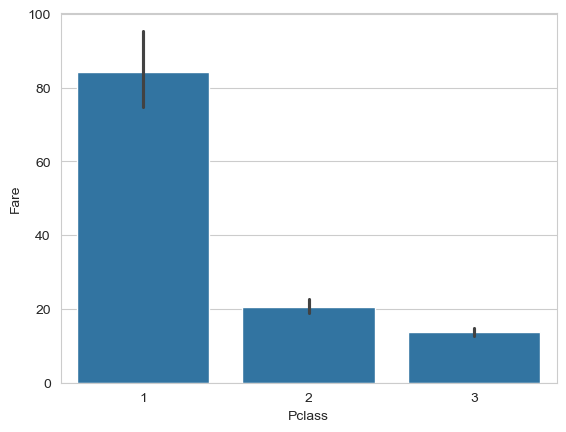

In [122]:
sns.barplot(data = train , x = 'Pclass' , y = 'Fare' )

#### Compare median age of survivors vs non-survivors using visualization.

<Axes: xlabel='Survived', ylabel='Age'>

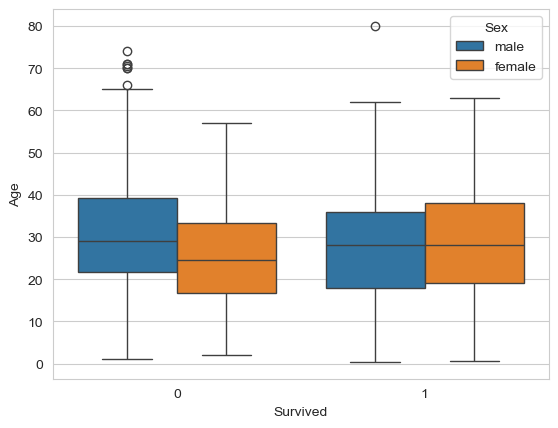

In [127]:
sns.boxplot(data = train , x = 'Survived' ,y = 'Age' , hue='Sex')

### Create a correlation heatmap of numerical features. Which variables are strongly related to survival?

In [129]:
train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

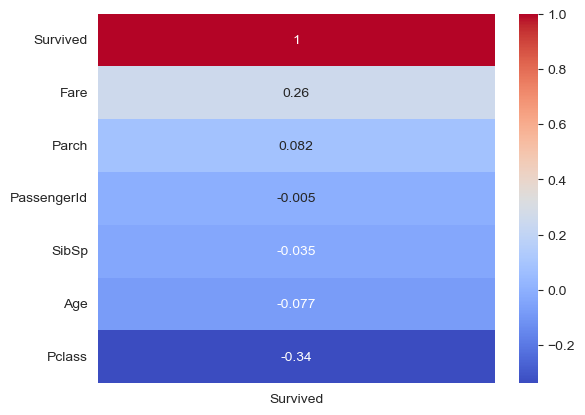

In [136]:
sns.heatmap(train.corr(numeric_only=True)[['Survived']].sort_values(by='Survived', ascending=False),annot=True,cmap='coolwarm')

### Does fare have a stronger relationship with survival than age? Justify using visualization.

<Axes: xlabel='Survived', ylabel='Fare'>

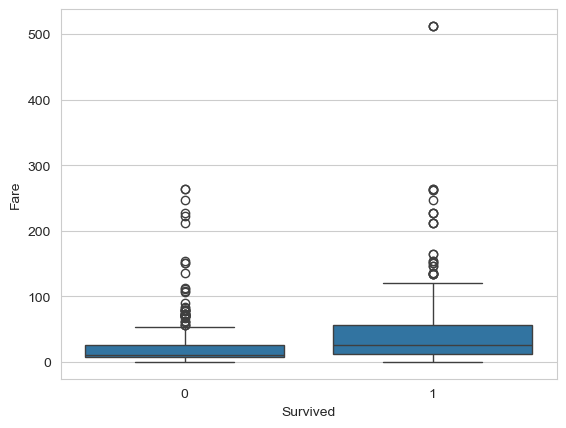

In [140]:
sns.boxplot(data=train,x='Survived',y='Fare')


<Axes: xlabel='Survived', ylabel='Age'>

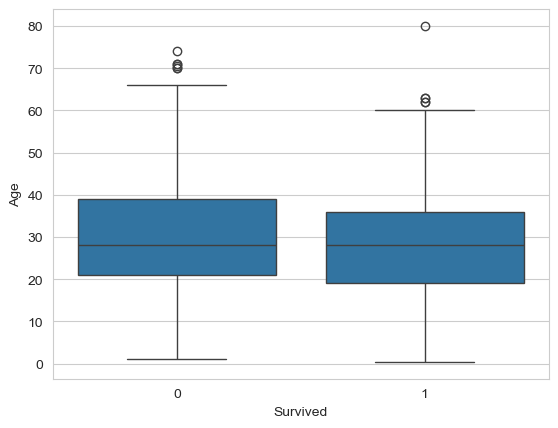

In [139]:

sns.boxplot(data=train,x='Survived',y='Age')

### Use FacetGrid to analyze age distribution across different classes and survival status.

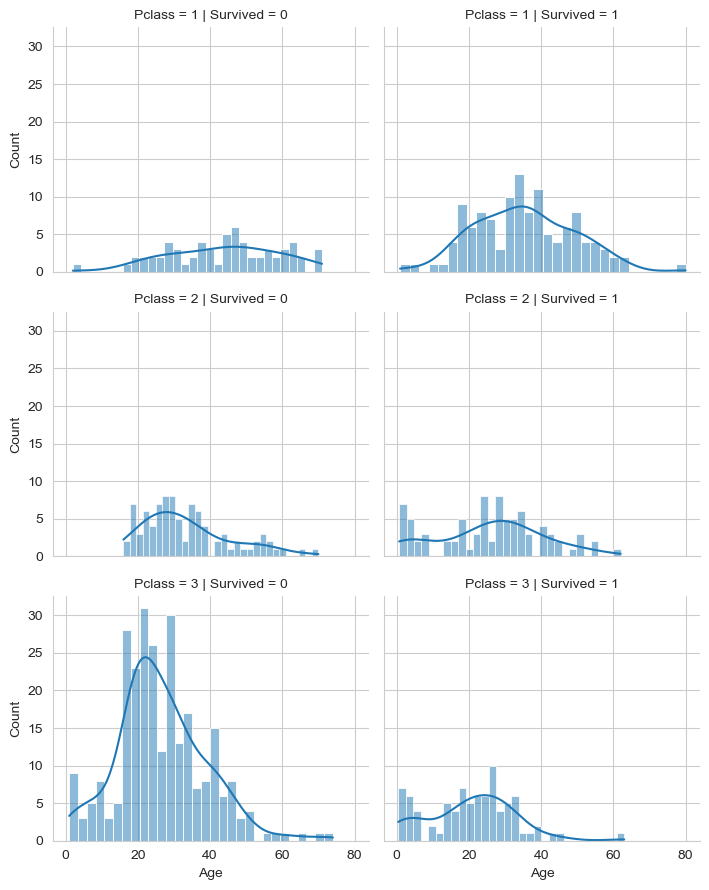

In [142]:
g = sns.FacetGrid(data=train, row='Pclass', col='Survived', height=3, aspect=1.2)
g.map(sns.histplot, 'Age', bins=30, kde=True)

### Create a visualization that shows survival trends across class, gender, and embarkation simultaneously.

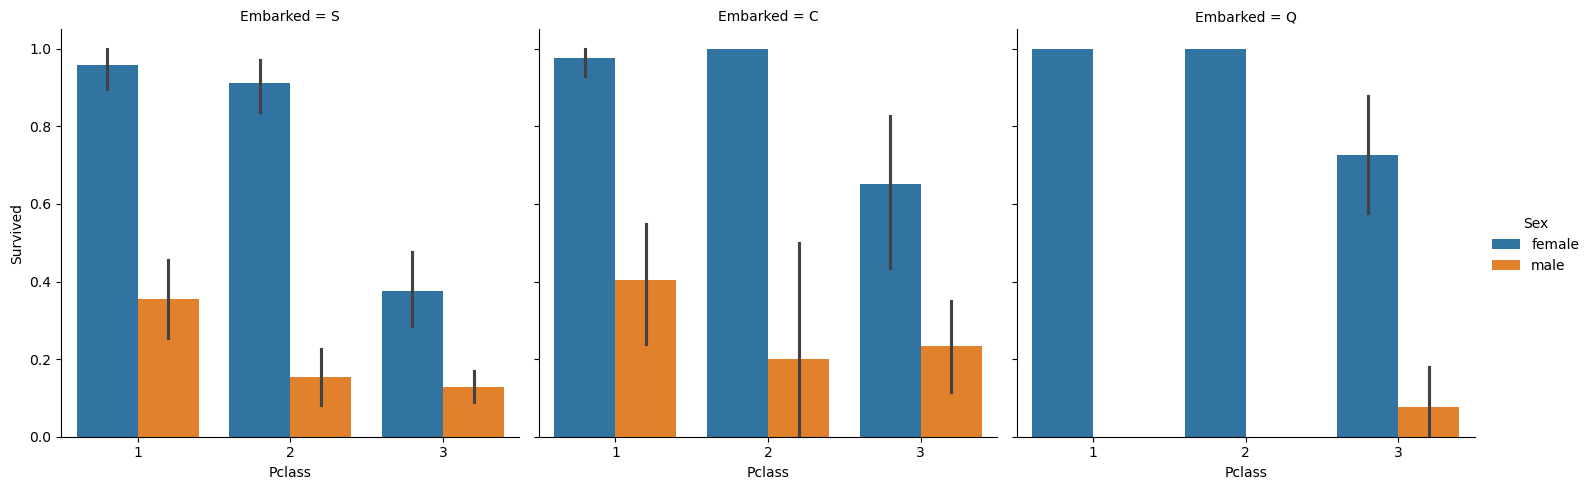

In [12]:
sns.catplot(data = train , x='Pclass' , y = 'Survived' , hue='Sex' , col='Embarked' , kind='bar')

### Use catplot to compare survival rates across multiple categorical features.

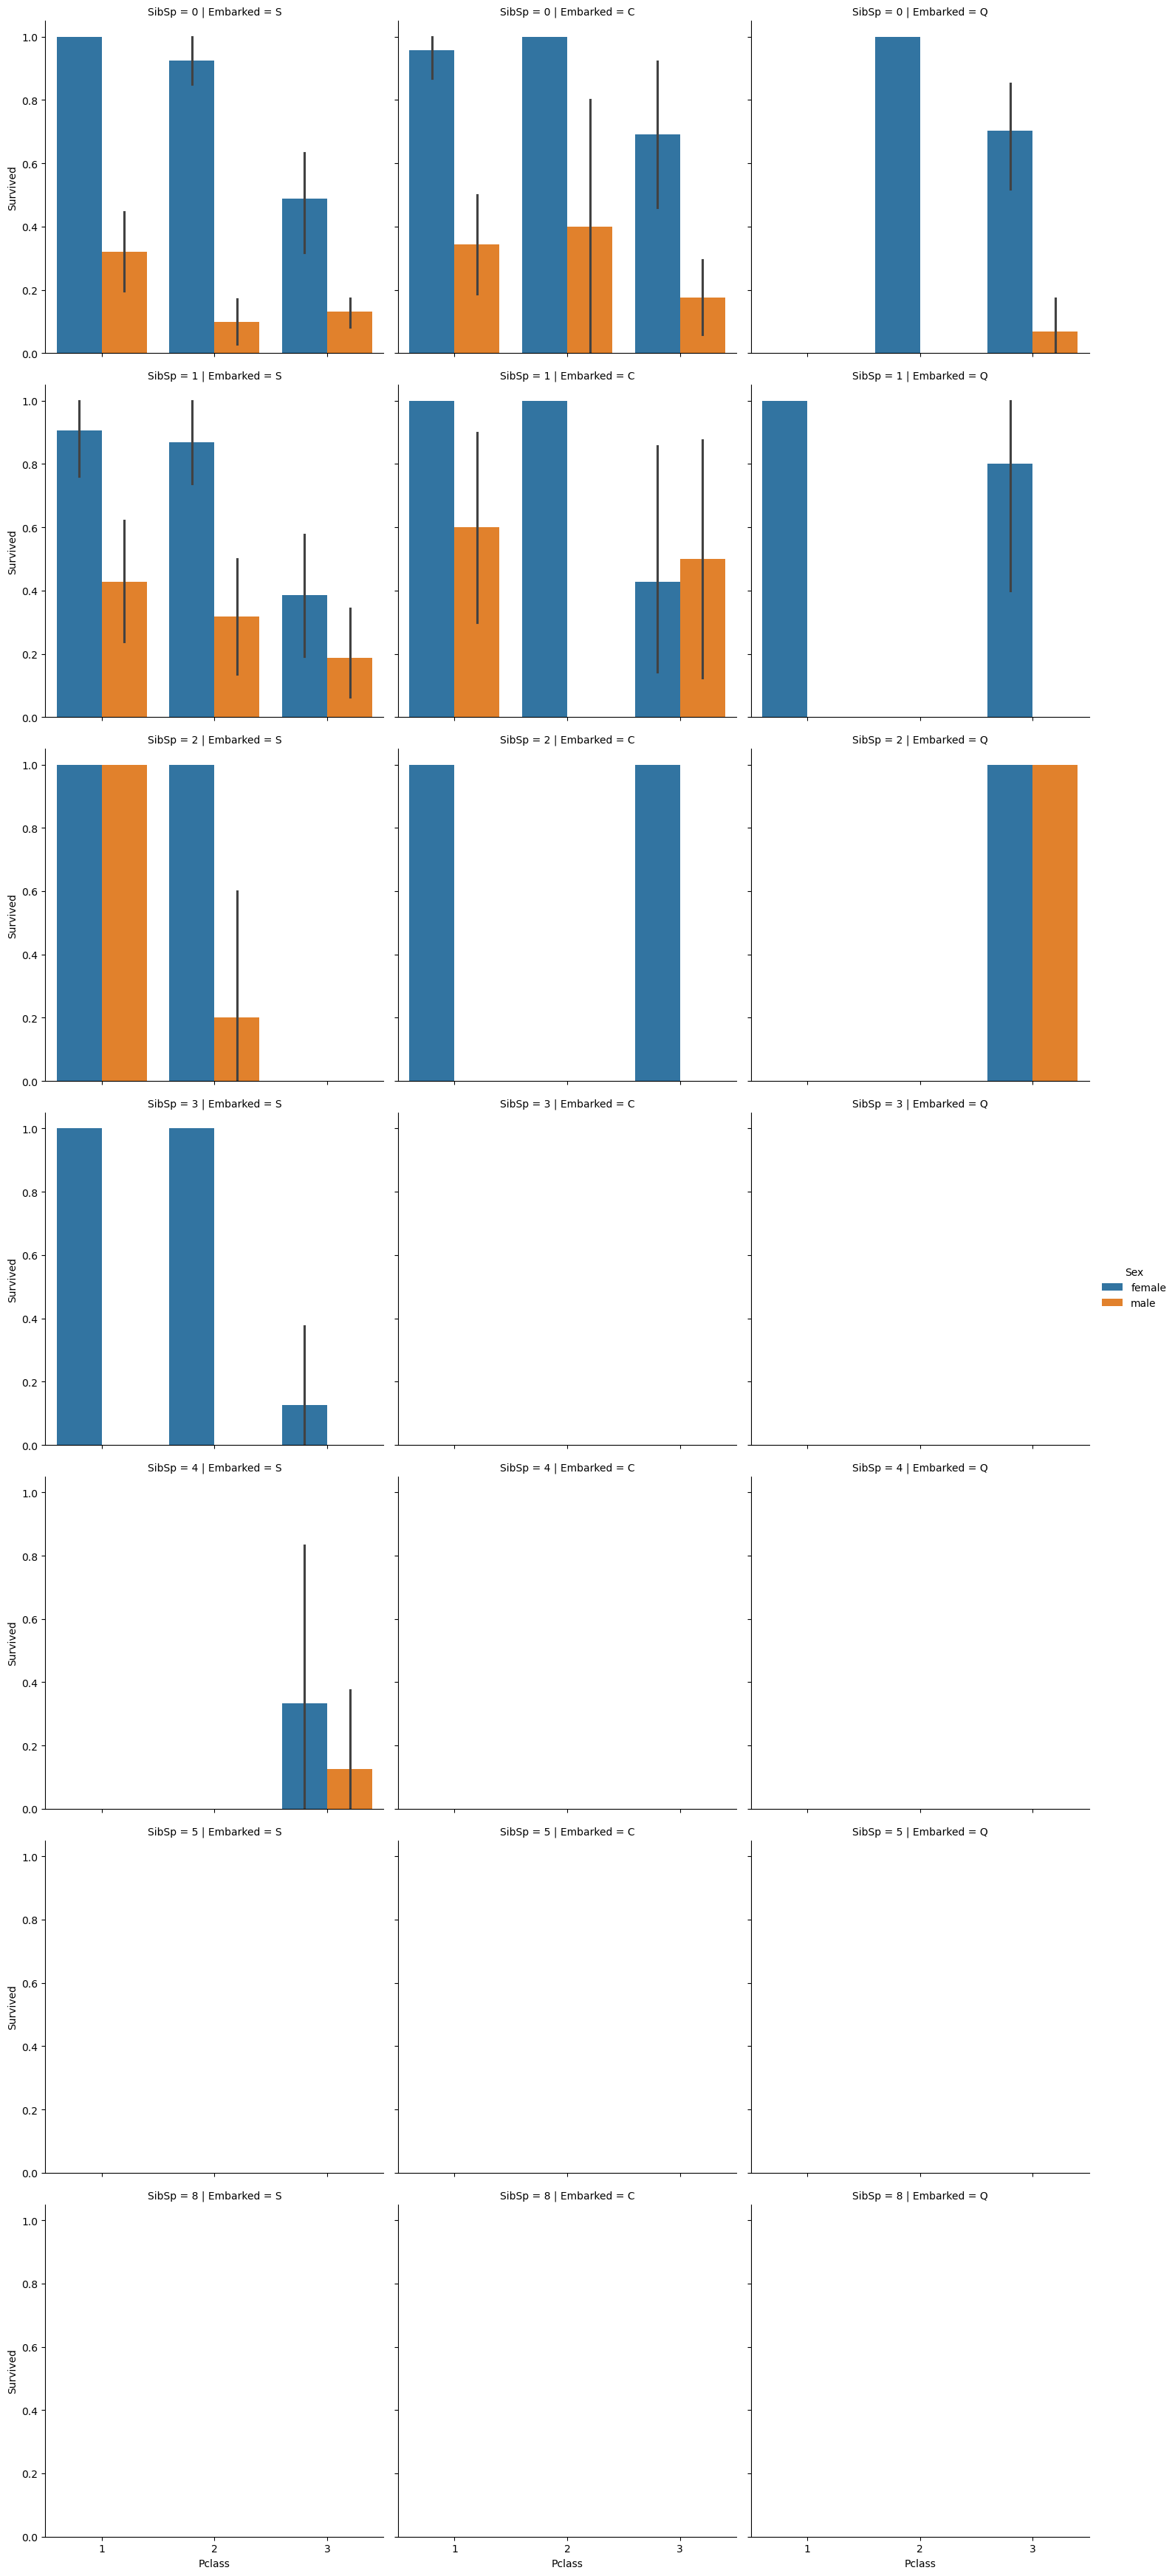

In [14]:
sns.catplot(data=train,x='Pclass',y='Survived',hue='Sex',col='Embarked',row='SibSp', kind='bar')

### Identify whether higher-class passengers had better survival due to wealth or other factors. What does visualization suggest?

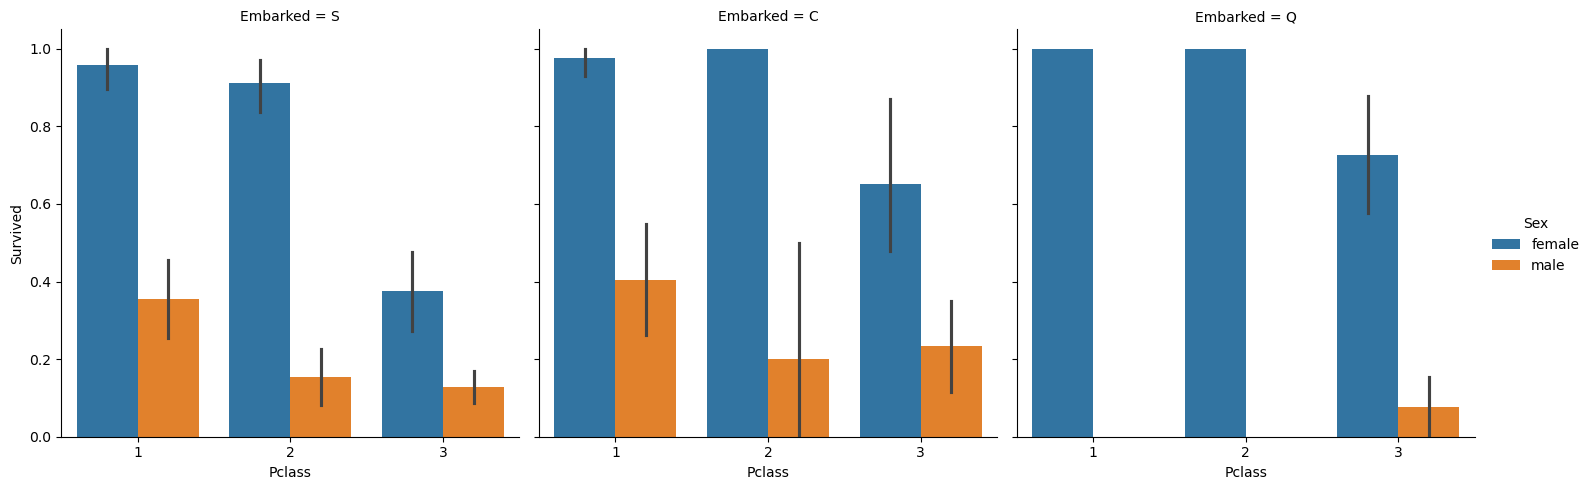

In [16]:
sns.catplot(data = train , y='Survived' , x='Pclass' , hue='Sex' , kind="bar" , col='Embarked')

### Is gender the strongest predictor of survival? Support using multiple plots.

<Axes: xlabel='Sex', ylabel='Survived'>

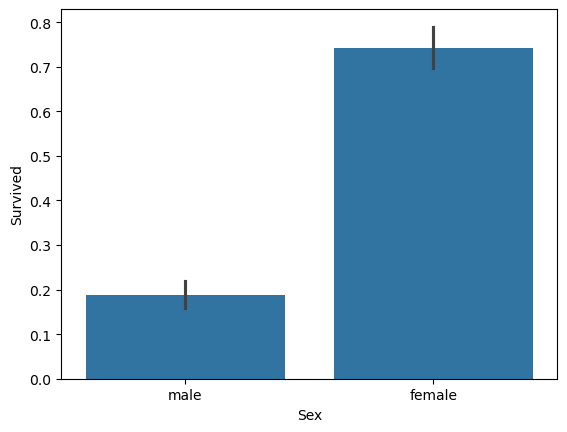

In [17]:
sns.barplot(data = train , x = 'Sex' , y='Survived')

<Axes: xlabel='Pclass', ylabel='Survived'>

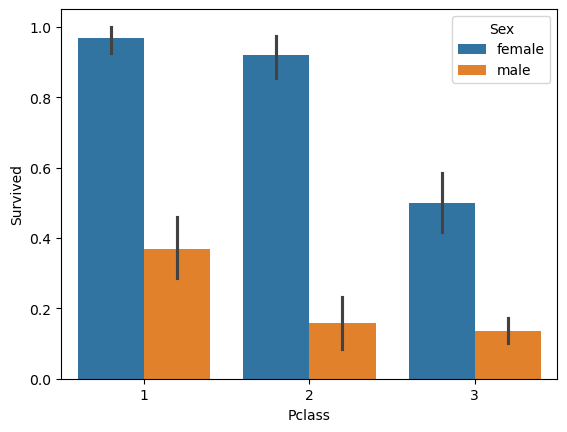

In [18]:
sns.barplot(data = train , x = 'Pclass' , y='Survived' , hue='Sex')

<Axes: xlabel='Age', ylabel='Count'>

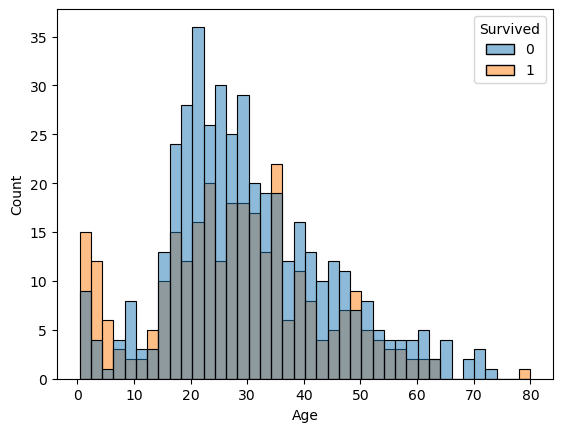

In [26]:
sns.histplot(data=train, x='Age', hue='Survived', bins=40)

### Analyze whether children had higher survival rates. Define "children" using age visualization.

In [27]:
def children(age):
    if age <= 15:
        return "Children"
    else:
        return "Not Children"

In [28]:
train['Child'] = train['Age'].apply(children)

<Axes: xlabel='Child', ylabel='Survived'>

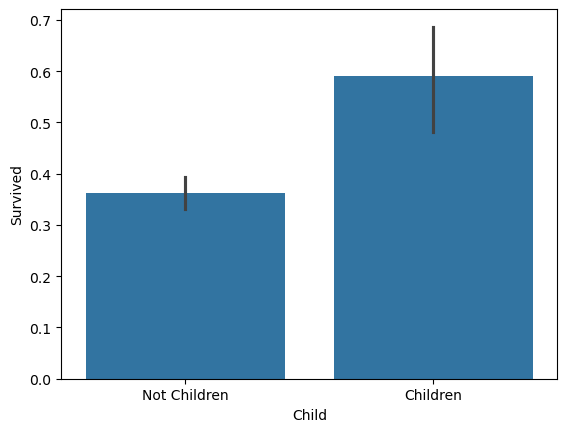

In [29]:
sns.barplot(data=train, x='Child', y='Survived')

### Compare fare distribution for survivors vs non-survivors across each class.

<Axes: xlabel='Pclass', ylabel='Fare'>

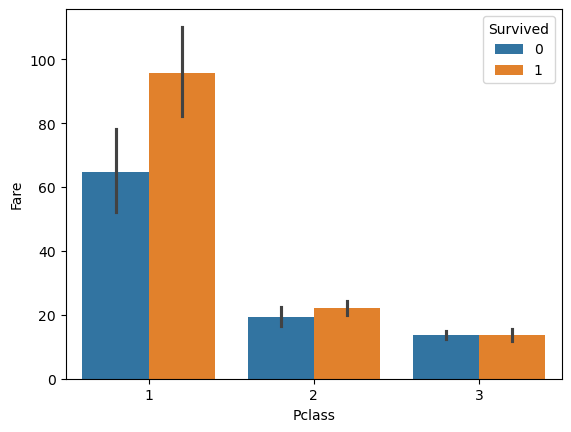

In [32]:
sns.barplot(data = train , x='Pclass' , y='Fare' , hue='Survived')

### Detect outliers in fare using boxplot. How might they affect conclusions?

<Axes: xlabel='Survived', ylabel='Fare'>

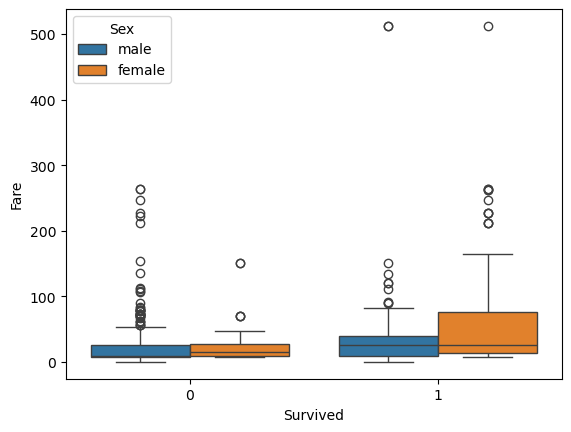

In [45]:
sns.boxplot(data=train, x='Survived', y='Fare', hue='Sex')